## 5 - Modeling MVP

Datasets:
- **Base**: `datasets/model_ready_base.csv`
- **Spatial**: `datasets/model_ready_spatial.csv`

Models:
1. OLS linear regression
2. Random Forest regressor
3. XGBoost regressor


## 2. Imports and reproducibility settings


In [69]:
from __future__ import annotations

import json
import re
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120


In [70]:
# XGBoost import (macOS fix: ensure OpenMP runtime is discoverable)
# If you installed libomp via Homebrew into /usr/local (Intel Homebrew), the dynamic loader
# might not search that path by default for wheels that expect /opt/homebrew.
import os

_libomp_candidates = [
    "/usr/local/opt/libomp/lib",
    "/opt/homebrew/opt/libomp/lib",
]

for p in _libomp_candidates:
    if os.path.isdir(p):
        os.environ["DYLD_LIBRARY_PATH"] = p + ":" + os.environ.get("DYLD_LIBRARY_PATH", "")
        os.environ["DYLD_FALLBACK_LIBRARY_PATH"] = p + ":" + os.environ.get("DYLD_FALLBACK_LIBRARY_PATH", "")

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    XGBOOST_IMPORT_ERROR = repr(e)

print("XGBoost available:", XGBOOST_AVAILABLE)
if not XGBOOST_AVAILABLE:
    print("XGBoost import error:", XGBOOST_IMPORT_ERROR)
    print("\nIf this is a libomp error on macOS, run:")
    print("- `brew install libomp`")
    print("Then restart the kernel (Kernel → Restart) and rerun.")


XGBoost available: True


In [71]:
# Package versions (reproducibility)
try:
    from importlib.metadata import version
except Exception:
    from importlib_metadata import version  # type: ignore

pkgs = ["numpy", "pandas", "matplotlib", "seaborn", "scikit-learn", "xgboost"]
versions = {}
for p in pkgs:
    try:
        versions[p] = version(p)
    except Exception:
        versions[p] = None
print(json.dumps(versions, indent=2))


{
  "numpy": "2.4.4",
  "pandas": "2.3.3",
  "matplotlib": "3.10.8",
  "seaborn": "0.13.2",
  "scikit-learn": "1.8.0",
  "xgboost": "3.2.0"
}


## 3. Load datasets


In [72]:
DATA_DIR = Path("datasets")
OUT_DIR = Path("outputs") / "modeling_mvp"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Full model-ready datasets (produced by notebook 4)
BASE_PATH = DATA_DIR / "model_ready_base.csv"
SPATIAL_PATH = DATA_DIR / "model_ready_spatial.csv"

# Persisted municipality-grouped train/test splits (created here)
BASE_TRAIN_PATH = DATA_DIR / "model_ready_base_train.csv"
BASE_TEST_PATH = DATA_DIR / "model_ready_base_test.csv"
SPATIAL_TRAIN_PATH = DATA_DIR / "model_ready_spatial_train.csv"
SPATIAL_TEST_PATH = DATA_DIR / "model_ready_spatial_test.csv"

base_df_full = pd.read_csv(BASE_PATH)
spatial_df_full = pd.read_csv(SPATIAL_PATH)

# ---------------------------------------------------------------------------
# Held-out test split (municipality-grouped, 80/20 by municipalities)
# ---------------------------------------------------------------------------
GROUP_COL = "gm_naam"
RANDOM_STATE = 42
TEST_FRACTION = 0.20

if GROUP_COL not in base_df_full.columns or GROUP_COL not in spatial_df_full.columns:
    raise KeyError(f"Expected grouping column '{GROUP_COL}' in both datasets.")

base_munis = set(base_df_full[GROUP_COL].dropna().unique().tolist())
spatial_munis = set(spatial_df_full[GROUP_COL].dropna().unique().tolist())
if base_munis != spatial_munis:
    raise ValueError("Base/spatial municipality sets differ; cannot do a consistent grouped split.")

munis = sorted(base_munis)
rng = np.random.default_rng(RANDOM_STATE)

test_n_munis = max(1, int(round(TEST_FRACTION * len(munis))))
test_munis = set(rng.choice(munis, size=test_n_munis, replace=False).tolist())
train_munis = set(munis) - test_munis

def split_by_muni(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    is_test = df[GROUP_COL].isin(test_munis)
    return df.loc[~is_test].copy(), df.loc[is_test].copy()

base_train_df, base_test_df = split_by_muni(base_df_full)
spatial_train_df, spatial_test_df = split_by_muni(spatial_df_full)

# Save splits immediately (used by notebooks 5–7)
base_train_df.to_csv(BASE_TRAIN_PATH, index=False)
base_test_df.to_csv(BASE_TEST_PATH, index=False)
spatial_train_df.to_csv(SPATIAL_TRAIN_PATH, index=False)
spatial_test_df.to_csv(SPATIAL_TEST_PATH, index=False)

# Audit summary
n_total = len(base_df_full)
print("=== Held-out test split audit (municipality-grouped) ===")
print(f"Rows: total={n_total}, train={len(base_train_df)} ({len(base_train_df)/n_total:.1%}), test={len(base_test_df)} ({len(base_test_df)/n_total:.1%})")
print(f"Municipalities: total={len(munis)}, train={len(train_munis)} ({len(train_munis)/len(munis):.1%}), test={len(test_munis)} ({len(test_munis)/len(munis):.1%})")
print("Saved train/test splits under datasets/.")

# From this point onward, MVP modeling uses TRAIN SPLIT ONLY
base_df = base_train_df
spatial_df = spatial_train_df


/var/folders/1l/q5ftm2z17hx00h6p9y5vjql80000gn/T/ipykernel_61582/2655371666.py:15: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  base_df_full = pd.read_csv(BASE_PATH)
/var/folders/1l/q5ftm2z17hx00h6p9y5vjql80000gn/T/ipykernel_61582/2655371666.py:16: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  spatial_df_full = pd.read_csv(SPATIAL_PATH)


=== Held-out test split audit (municipality-grouped) ===
Rows: total=14019, train=11379 (81.2%), test=2640 (18.8%)
Municipalities: total=341, train=273 (80.1%), test=68 (19.9%)
Saved train/test splits under datasets/.


## 4. Inspect columns and select target / ID / grouping variables


In [73]:
# Fixed target/grouping variables (consistent across pipeline)
TARGET_COL = "log_crime_count"
GROUP_COL = "gm_naam"

if TARGET_COL not in base_df.columns or TARGET_COL not in spatial_df.columns:
    raise KeyError(f"Expected '{TARGET_COL}' in both datasets.")
if GROUP_COL not in base_df.columns:
    raise KeyError(f"Expected grouping column '{GROUP_COL}' in dataset.")

print("Target:", TARGET_COL, "| Group col:", GROUP_COL)


Target: log_crime_count | Group col: gm_naam


## 5. Define feature matrices


In [74]:
# Feature selection (numeric predictors only; exclude identifiers and leakage-like columns)

ID_COLS_BASE = [
    "gwb_code_10",
    "gwb_code_8",
    "gwb_code",
    "merge_key",
    "regio",
    "gm_naam",
    "ID",
    "Perioden",
    "SoortMisdrijf",
    "recs",
    "centroid_x",
    "centroid_y",
]
ID_COLS_SPATIAL = ID_COLS_BASE.copy()

RAW_TARGET_LIKE = {
    "crime_count",
    "crime_rate_per_1000",
    "population",
    "population_zero",
    "GeregistreerdeMisdrijven_1",
    "a_inw",
}

LEAKAGE_PATTERNS = [
    r"spillover_spec",
    r"spillover_target",
    r"target_lag",
    r"lag_y",
    r"spillover_lag",
    r"lag_.*crime",
    r"crime.*lag",
]
LEAKAGE_REGEX = re.compile("|".join(LEAKAGE_PATTERNS), flags=re.IGNORECASE)


def select_numeric_predictors(
    df: pd.DataFrame, target: str, id_cols: List[str]
) -> Tuple[pd.DataFrame, pd.Series, Dict[str, Any]]:
    df = df.copy()

    leak = [c for c in df.columns if LEAKAGE_REGEX.search(c)]
    exclude = set([c for c in id_cols if c in df.columns]) | set(leak) | set(RAW_TARGET_LIKE) | {target}

    num_cols = df.select_dtypes(include=["number"]).columns.tolist()
    feature_cols = [c for c in num_cols if c not in exclude]

    X = df[feature_cols].copy()
    y = df[target].copy()

    assert target not in X.columns
    assert not any(LEAKAGE_REGEX.search(c) for c in X.columns)

    info = {
        "n_features": len(feature_cols),
        "spillover_cols": [c for c in feature_cols if c.startswith("queen_lag_")],
        "excluded_leakage_cols": leak,
    }
    return X, y, info


X_base, y_base, info_base = select_numeric_predictors(base_df, TARGET_COL, ID_COLS_BASE)
X_spatial, y_spatial, info_spatial = select_numeric_predictors(spatial_df, TARGET_COL, ID_COLS_SPATIAL)

print("Predictors (train): base=", X_base.shape[1], "| spatial=", X_spatial.shape[1], "| spillovers=", len(info_spatial["spillover_cols"]))


Predictors (train): base= 83 | spatial= 95 | spillovers= 12


## 6. Define leakage-safe pipelines


In [75]:
def make_ols_pipeline() -> Pipeline:
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ])


def make_rf_pipeline() -> Pipeline:
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])


def make_xgb_pipeline() -> Pipeline:
    if not XGBOOST_AVAILABLE:
        raise ImportError(
            "xgboost is not available. Install it and rerun. "
            f"Import error was: {XGBOOST_IMPORT_ERROR}"
        )
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", xgb.XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.0,
            reg_lambda=1.0,
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])


## 7. Cross-validation strategy


In [76]:
def make_cv(groups: Optional[pd.Series]) -> Tuple[Any, str]:
    if groups is not None:
        return GroupKFold(n_splits=5), f"GroupKFold(n_splits=5) on '{groups.name}'"
    return KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), "KFold(n_splits=5, shuffle=True, random_state=42)"


def print_fold_diagnostics(cv, X: pd.DataFrame, y: pd.Series, groups: Optional[pd.Series]):
    print("Fold diagnostics:")
    for i, (tr, va) in enumerate(cv.split(X, y, groups)):
        print(f"- fold {i}: train={len(tr):,}, val={len(va):,}")
        if groups is not None:
            gtr = set(groups.iloc[tr].astype(str))
            gva = set(groups.iloc[va].astype(str))
            overlap = gtr.intersection(gva)
            print(f"  group overlap: {len(overlap)}")
            if overlap:
                raise ValueError("Group overlap detected between train and validation folds")


groups_base = base_df[GROUP_COL] if GROUP_COL and GROUP_COL in base_df.columns else None
groups_spatial = spatial_df[GROUP_COL] if GROUP_COL and GROUP_COL in spatial_df.columns else None

cv_base, cv_base_desc = make_cv(groups_base)
cv_spatial, cv_spatial_desc = make_cv(groups_spatial)

print("Base CV strategy:", cv_base_desc)
print_fold_diagnostics(cv_base, X_base, y_base, groups_base)

print("\nSpatial CV strategy:", cv_spatial_desc)
print_fold_diagnostics(cv_spatial, X_spatial, y_spatial, groups_spatial)


Base CV strategy: GroupKFold(n_splits=5) on 'gm_naam'
Fold diagnostics:
- fold 0: train=9,102, val=2,277
  group overlap: 0
- fold 1: train=9,104, val=2,275
  group overlap: 0
- fold 2: train=9,103, val=2,276
  group overlap: 0
- fold 3: train=9,103, val=2,276
  group overlap: 0
- fold 4: train=9,104, val=2,275
  group overlap: 0

Spatial CV strategy: GroupKFold(n_splits=5) on 'gm_naam'
Fold diagnostics:
- fold 0: train=9,102, val=2,277
  group overlap: 0
- fold 1: train=9,104, val=2,275
  group overlap: 0
- fold 2: train=9,103, val=2,276
  group overlap: 0
- fold 3: train=9,103, val=2,276
  group overlap: 0
- fold 4: train=9,104, val=2,275
  group overlap: 0


## Helper functions for evaluation


In [77]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def evaluate_cv_oof(
    model: Pipeline,
    X: pd.DataFrame,
    y: pd.Series,
    cv,
    groups: Optional[pd.Series],
    model_name: str,
    dataset_name: str,
    id_df: pd.DataFrame,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    oof_pred = np.full(len(y), np.nan, dtype=float)
    fold_rows = []

    for fold, (tr, va) in enumerate(cv.split(X, y, groups)):
        X_tr, y_tr = X.iloc[tr], y.iloc[tr]
        X_va, y_va = X.iloc[va], y.iloc[va]

        model_fold = Pipeline(steps=model.steps)
        model_fold.fit(X_tr, y_tr)

        pred_tr = model_fold.predict(X_tr)
        pred_va = model_fold.predict(X_va)

        oof_pred[va] = pred_va

        fold_rows.append({
            "dataset": dataset_name,
            "model": model_name,
            "fold": fold,
            "n_train": len(tr),
            "n_val": len(va),
            "rmse_train": rmse(y_tr, pred_tr),
            "rmse_val": rmse(y_va, pred_va),
            "mae_train": float(mean_absolute_error(y_tr, pred_tr)),
            "mae_val": float(mean_absolute_error(y_va, pred_va)),
            "r2_train": float(r2_score(y_tr, pred_tr)),
            "r2_val": float(r2_score(y_va, pred_va)),
        })

    fold_df = pd.DataFrame(fold_rows)

    oof_df = id_df.copy()
    oof_df["dataset"] = dataset_name
    oof_df["model"] = model_name
    oof_df["y_true"] = y.values
    oof_df["y_pred_oof"] = oof_pred
    oof_df["residual"] = oof_df["y_true"] - oof_df["y_pred_oof"]
    oof_df["abs_error"] = oof_df["residual"].abs()

    if np.isnan(oof_pred).any():
        raise RuntimeError("OOF predictions contain NaN")

    return fold_df, oof_df


def summarize_folds(fold_df: pd.DataFrame) -> pd.DataFrame:
    return (
        fold_df.groupby(["dataset", "model"])
        .agg(
            rmse_val_mean=("rmse_val", "mean"),
            rmse_val_std=("rmse_val", "std"),
            mae_val_mean=("mae_val", "mean"),
            mae_val_std=("mae_val", "std"),
            r2_val_mean=("r2_val", "mean"),
            r2_val_std=("r2_val", "std"),
        )
        .reset_index()
        .sort_values(["dataset", "rmse_val_mean"])
    )


## 8–10. Fit and evaluate OLS / RF / XGBoost


In [78]:
KEEP_CONTEXT_COLS = [c for c in ["gwb_code_10", "gm_naam", "regio", "population", "crime_count"] if c in base_df.columns]

id_base = base_df[KEEP_CONTEXT_COLS].copy() if KEEP_CONTEXT_COLS else pd.DataFrame(index=base_df.index)
id_spatial = spatial_df[KEEP_CONTEXT_COLS].copy() if KEEP_CONTEXT_COLS else pd.DataFrame(index=spatial_df.index)

# Cache expensive CV outputs so the notebook can be re-opened without re-running training.
CACHE_FOLD = OUT_DIR / "fold_metrics_all.csv"
CACHE_OOF = OUT_DIR / "oof_predictions_all.csv"

if CACHE_FOLD.exists() and CACHE_OOF.exists():
    fold_metrics = pd.read_csv(CACHE_FOLD)
    oof_predictions = pd.read_csv(CACHE_OOF)
    print("Loaded cached fold metrics:", CACHE_FOLD)
    print("Loaded cached OOF predictions:", CACHE_OOF)
else:
    models = {
        "OLS": make_ols_pipeline(),
        "RF": make_rf_pipeline(),
    }
    if XGBOOST_AVAILABLE:
        models["XGB"] = make_xgb_pipeline()

    fold_tables = []
    oof_tables = []

    for name, pipe in models.items():
        fdf, oof = evaluate_cv_oof(pipe, X_base, y_base, cv_base, groups_base, name, "base", id_base)
        fold_tables.append(fdf)
        oof_tables.append(oof)

    for name, pipe in models.items():
        fdf, oof = evaluate_cv_oof(pipe, X_spatial, y_spatial, cv_spatial, groups_spatial, name, "spatial", id_spatial)
        fold_tables.append(fdf)
        oof_tables.append(oof)

    fold_metrics = pd.concat(fold_tables, ignore_index=True)
    oof_predictions = pd.concat(oof_tables, ignore_index=True)

    fold_metrics.to_csv(CACHE_FOLD, index=False)
    oof_predictions.to_csv(CACHE_OOF, index=False)
    print("Saved fold metrics to:", CACHE_FOLD)
    print("Saved OOF predictions to:", CACHE_OOF)

print("Fold-level metrics (head):")
print(fold_metrics.head(10).to_string(index=False))

summary = summarize_folds(fold_metrics)
print("\nOverall CV summary:")
print(summary.to_string(index=False))


Loaded cached fold metrics: outputs/modeling_mvp/fold_metrics_all.csv
Loaded cached OOF predictions: outputs/modeling_mvp/oof_predictions_all.csv
Fold-level metrics (head):
dataset model  fold  n_train  n_val  rmse_train  rmse_val  mae_train  mae_val  r2_train   r2_val
   base   OLS     0    11215   2804    0.675631  0.707540   0.505910 0.525755  0.754635 0.737528
   base   OLS     1    11215   2804    0.678210  0.676786   0.506483 0.508330  0.763712 0.727269
   base   OLS     2    11215   2804    0.667072  0.752900   0.497486 0.530350  0.766323 0.693379
   base   OLS     3    11215   2804    0.679351  0.672555   0.507280 0.506173  0.754986 0.761835
   base   OLS     4    11216   2803    0.675756  0.688366   0.504544 0.519694  0.755858 0.762108
   base    RF     0    11215   2804    0.243627  0.587713   0.168443 0.431903  0.968096 0.818903
   base    RF     1    11215   2804    0.242168  0.571725   0.167651 0.420383  0.969874 0.805372
   base    RF     2    11215   2804    0.240981  0.

## 11–12. Compare models on base vs spatial


Model comparison:
dataset model  mean_RMSE  std_RMSE  mean_MAE  std_MAE  mean_R2   std_R2
   base   XGB   0.558855  0.005105  0.408188 0.002376 0.832133 0.008729
   base    RF   0.581245  0.006680  0.423731 0.004811 0.818472 0.008007
   base   OLS   0.699630  0.032719  0.518060 0.010594 0.736424 0.028475
spatial   XGB   0.548469  0.007005  0.404429 0.004010 0.838384 0.006744
spatial    RF   0.570206  0.008528  0.418998 0.006222 0.825346 0.006661
spatial   OLS   0.672763  0.029048  0.501724 0.009297 0.756500 0.022813


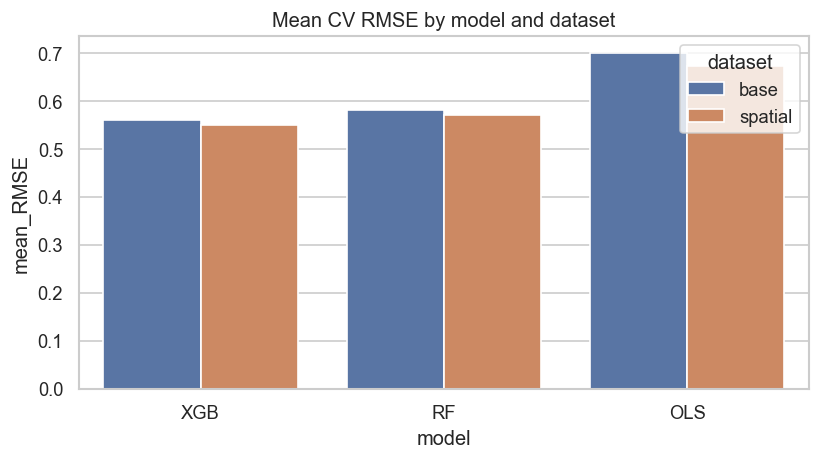

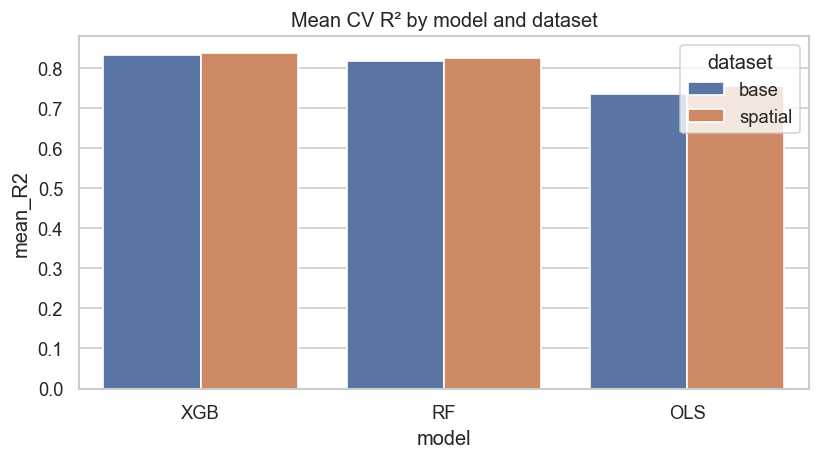

In [79]:
comparison = summary.rename(columns={
    "rmse_val_mean": "mean_RMSE",
    "rmse_val_std": "std_RMSE",
    "mae_val_mean": "mean_MAE",
    "mae_val_std": "std_MAE",
    "r2_val_mean": "mean_R2",
    "r2_val_std": "std_R2",
}).copy()

print("Model comparison:")
print(comparison.to_string(index=False))

plt.figure(figsize=(7, 4))
sns.barplot(data=comparison, x="model", y="mean_RMSE", hue="dataset")
plt.title("Mean CV RMSE by model and dataset")
plt.tight_layout()
plt.savefig(OUT_DIR / "rmse_by_model_dataset.png")
plt.show()

plt.figure(figsize=(7, 4))
sns.barplot(data=comparison, x="model", y="mean_R2", hue="dataset")
plt.title("Mean CV R² by model and dataset")
plt.tight_layout()
plt.savefig(OUT_DIR / "r2_by_model_dataset.png")
plt.show()



Top 15 OLS coefficients (base):
 feature      coef
a_opp_ha  9.774108
a_lan_ha -9.297547
   a_pau -2.549752
 a_ongeh -2.461800
 a_bst_b  2.304736
  a_bedv  2.090336
a_gehuwd -1.610425
a_neu_al  1.606548
a_geb_nl  1.527104
   a_man  1.223393
 p_1gezw -0.940694
a_wat_ha -0.899905
a_bed_mn -0.840811
 p_mgezw -0.807363
a_bst_nb  0.729349


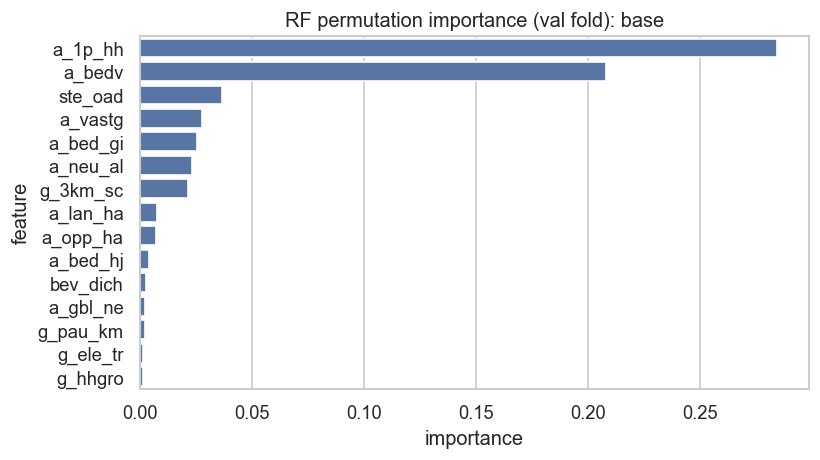

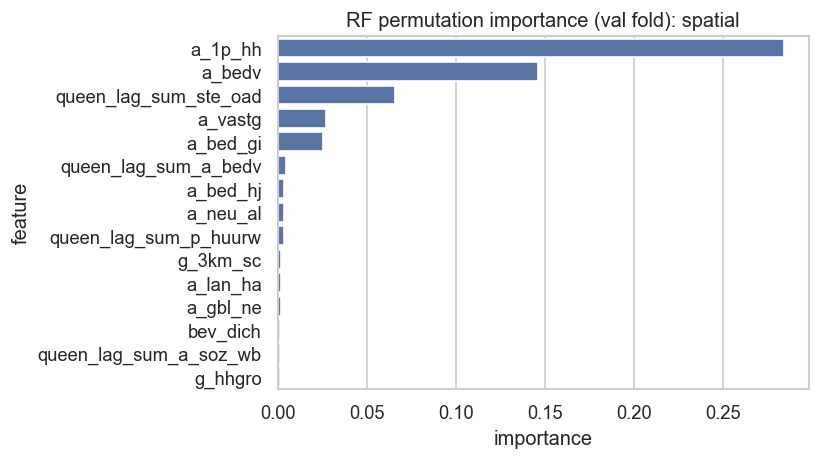

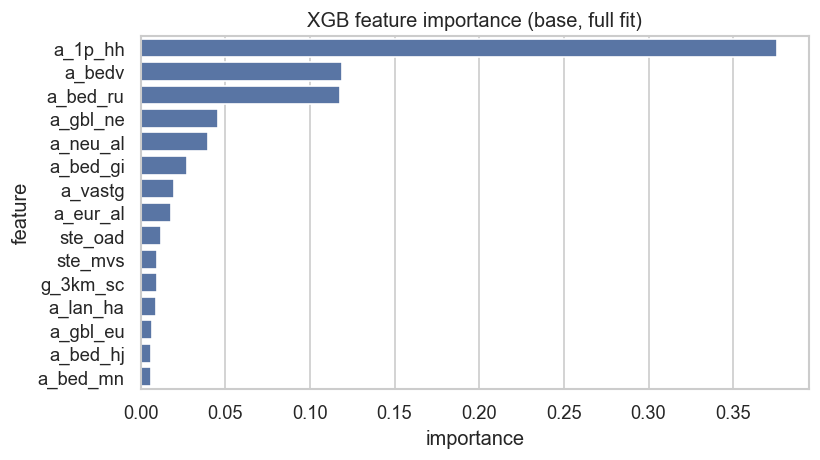

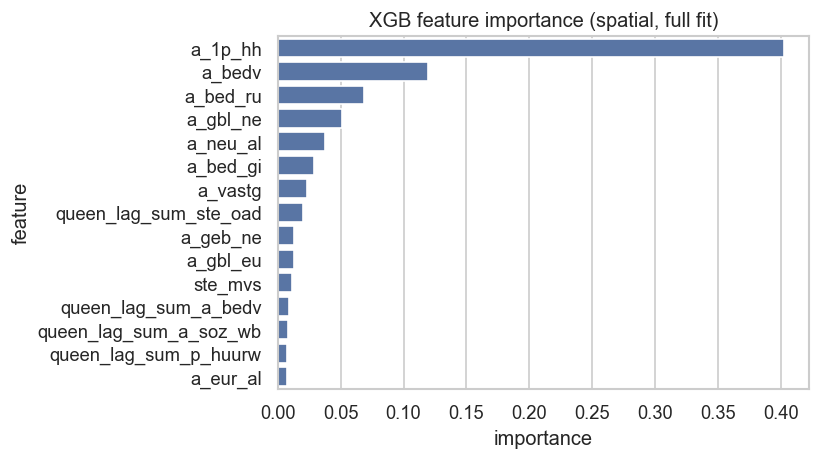

In [80]:
def fit_full(model: Pipeline, X: pd.DataFrame, y: pd.Series) -> Pipeline:
    m = Pipeline(steps=model.steps)
    return m.fit(X, y)

# OLS coefficients (scaled)
ols_full_base = fit_full(make_ols_pipeline(), X_base, y_base)
coef = ols_full_base.named_steps["model"].coef_
ols_coef_df = pd.DataFrame({"feature": X_base.columns, "coef": coef}).sort_values("coef", key=np.abs, ascending=False)
print("\nTop 15 OLS coefficients (base):")
print(ols_coef_df.head(15).to_string(index=False))
ols_coef_df.head(50).to_csv(OUT_DIR / "top_features_ols_base.csv", index=False)

# RF permutation importance on one validation fold (more defensible than full-data importance)
# NOTE: run single-process to avoid joblib pickling issues on some setups.

def rf_perm_imp_one_fold(X, y, cv, groups, tag: str):
    pipe = make_rf_pipeline()
    tr, va = next(iter(cv.split(X, y, groups)))
    pipe.fit(X.iloc[tr], y.iloc[tr])

    try:
        r = permutation_importance(
            pipe,
            X.iloc[va],
            y.iloc[va],
            n_repeats=10,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
    except Exception as e:
        print("Permutation importance failed; retrying single-process. Error:", repr(e))
        r = permutation_importance(
            pipe,
            X.iloc[va],
            y.iloc[va],
            n_repeats=10,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )

    imp = pd.DataFrame({"feature": X.columns, "importance": r.importances_mean}).sort_values("importance", ascending=False)
    imp.head(15).to_csv(OUT_DIR / f"top_features_rf_{tag}.csv", index=False)

    plt.figure(figsize=(7, 4))
    sns.barplot(data=imp.head(15), x="importance", y="feature")
    plt.title(f"RF permutation importance (val fold): {tag}")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"rf_top15_{tag}.png")
    plt.show()

rf_perm_imp_one_fold(X_base, y_base, cv_base, groups_base, "base")
rf_perm_imp_one_fold(X_spatial, y_spatial, cv_spatial, groups_spatial, "spatial")

if XGBOOST_AVAILABLE:
    xgb_full_base = fit_full(make_xgb_pipeline(), X_base, y_base)
    xgb_model = xgb_full_base.named_steps["model"]
    imp = pd.DataFrame({"feature": X_base.columns, "importance": xgb_model.feature_importances_}).sort_values("importance", ascending=False)
    imp.head(15).to_csv(OUT_DIR / "top_features_xgb_base.csv", index=False)

    plt.figure(figsize=(7, 4))
    sns.barplot(data=imp.head(15), x="importance", y="feature")
    plt.title("XGB feature importance (base, full fit)")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "xgb_top15_base.png")
    plt.show()

    xgb_full_spatial = fit_full(make_xgb_pipeline(), X_spatial, y_spatial)
    xgb_model_s = xgb_full_spatial.named_steps["model"]
    imp_s = pd.DataFrame({"feature": X_spatial.columns, "importance": xgb_model_s.feature_importances_}).sort_values("importance", ascending=False)
    imp_s.head(15).to_csv(OUT_DIR / "top_features_xgb_spatial.csv", index=False)

    plt.figure(figsize=(7, 4))
    sns.barplot(data=imp_s.head(15), x="importance", y="feature")
    plt.title("XGB feature importance (spatial, full fit)")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "xgb_top15_spatial.png")
    plt.show()
else:
    print("XGBoost not available: skipping XGB feature importance")


## MVP summary (train split CV only)

This notebook provides a quick MVP comparison on the **training split only**. All thesis figures/SHAP/final performance are produced in notebook 6 on the held-out test set.


In [81]:
best_overall = comparison.sort_values("mean_RMSE").iloc[0]
print("Best MVP configuration by mean CV RMSE (train split only):")
print(best_overall.to_string())


Best MVP configuration by mean CV RMSE (train split only):
dataset       spatial
model             XGB
mean_RMSE    0.548469
std_RMSE     0.007005
mean_MAE     0.404429
std_MAE       0.00401
mean_R2      0.838384
std_R2       0.006744


In [82]:
# Minimal exports (train split CV only)
(OUT_DIR / "fold_metrics.csv").write_text("") if False else None  # placeholder to keep cell non-empty

# NOTE: Fold metrics and OOF predictions are already cached earlier in this notebook.
# We additionally export the compact MVP comparison table here.
comparison.to_csv(OUT_DIR / "mvp_model_comparison_summary.csv", index=False)
print("Saved MVP comparison table to:", OUT_DIR / "mvp_model_comparison_summary.csv")


Saved MVP comparison table to: outputs/modeling_mvp/mvp_model_comparison_summary.csv
